# otwin 05 · From a noisy sensor to a state you can trust

**Question.** A capacity reading says the cell is at 106 % of its original capacity. It is not.
How do you turn noisy, gappy measurements into a state estimate that respects what you know —
that health cannot exceed 1, that energy cannot appear from nowhere?

**What otwin does here.** `otwin.signal` conditions the raw series and tells you how much of
it is real measurement. `otwin.estimate` corrects the state: an extended Kalman filter, a
moving-horizon estimator with **bounds**, and an observer that refuses corrections that would
create energy.

**What you write yourself.** The model in otwin's `TwinModel` shape — `rhs` and `observe`,
two methods — and the sensor's fault, injected on purpose so you can see who handles it.

**What you will learn**

1. why a coverage figure belongs next to every metric computed on resampled data
2. what an EKF does with a physically impossible reading, and what a bounded estimator does instead
3. why "the constraint is information" shows up as 39 % lower error, not just as a nicer plot
4. how an energy-consistent observer treats a sensor that lies

*Data: NASA PCoE cell B0005, plus the flywheel from notebook 01. Runtime ≈ 1 min. Opens in Colab.*


## Setup

In [1]:
# otwin from PyPI. This is the whole point of the notebook: no clone, no path
# surgery, no vendored copy of the model code.
!pip install -q otwin 2>/dev/null
import otwin, sys
print("otwin", otwin.__version__, "| python", sys.version.split()[0])


otwin 0.3.1 | python 3.13.15


In [2]:
# Inlined plotting style. Self-contained on purpose: nothing here imports
# from another file in this repository.
import os, json
import numpy as np, warnings; warnings.filterwarnings("ignore")
import pandas as pd
from scipy.optimize import curve_fit
from otwin.estimate import ExtendedKalmanFilter, MovingHorizonEstimator, EnergyConsistentObserver
from otwin.signal import resample, find_gaps, coverage
from otwin.model import PortHamiltonianSystem, integrate_phs
import matplotlib; import matplotlib.pyplot as plt

TEAL, RED, SLATE, GRID, OBS = "#0E7C86", "#C1121F", "#4A5568", "#E5E9EC", "black"
BAND_ALPHA = 0.18
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
    "font.family":"DejaVu Sans","axes.titlesize":13,"axes.labelsize":11,
    "xtick.labelsize":10,"ytick.labelsize":10,"legend.fontsize":10,
    "axes.grid":True,"grid.color":GRID,"grid.linewidth":0.8,"axes.axisbelow":True,
    "figure.dpi":110,"savefig.dpi":200,
})
FIGDIR="fig"; os.makedirs(FIGDIR, exist_ok=True)
def despine(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333333"); ax.spines["bottom"].set_color("#333333")
def save(fig, name):
    p=os.path.join(FIGDIR, name if name.endswith(".png") else name+".png")
    fig.savefig(p, dpi=200, bbox_inches="tight"); plt.show(); print("saved", p); return p


In [3]:
# The NASA PCoE discharge CSV is the only external input. Resolution order,
# with the chosen route printed:
#   (a) a download URL, if you set CANDIDATE_URL
#   (b) google.colab.files.upload()  - the normal Colab route
#   (c) a local file, for offline / CI runs

CANDIDATE_URL = ""
LOCAL_CANDIDATES = ["discharge.csv", "data/discharge.csv", "/content/discharge.csv"]
EXPECTED_ROWS = 169766
EXPECTED_CELLS = ["B0005", "B0006", "B0007", "B0018"]

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

DATA, route = None, None
if CANDIDATE_URL:
    try:
        import urllib.request
        urllib.request.urlretrieve(CANDIDATE_URL, "discharge.csv")
        DATA, route = "discharge.csv", "(a) downloaded from CANDIDATE_URL"
    except Exception as e:
        print("URL download failed:", e)
if DATA is None:
    for p in LOCAL_CANDIDATES:
        if os.path.exists(p):
            DATA, route = p, f"(c) local file: {p}"; break
if DATA is None and _in_colab():
    from google.colab import files
    up = files.upload(); DATA = list(up.keys())[0]; route = f"(b) uploaded in Colab: {DATA}"
if DATA is None:
    raise FileNotFoundError("No data source. Set CANDIDATE_URL, upload the CSV in Colab, "
                            "or put discharge.csv next to this notebook.")
print("DATA route:", route); print("DATA path :", DATA)

raw = pd.read_csv(DATA)
assert sorted(raw.Battery.unique().tolist()) == EXPECTED_CELLS, "unexpected battery IDs"
assert len(raw) == EXPECTED_ROWS, f"expected {EXPECTED_ROWS} rows, found {len(raw)}"
print("rows:", len(raw), "| cells:", sorted(raw.Battery.unique().tolist()))
print("Sanity checks passed.")


DATA route: (c) local file: discharge.csv
DATA path : discharge.csv
rows: 169766 | cells: ['B0005', 'B0006', 'B0007', 'B0018']
Sanity checks passed.


## 1 · Condition the signal, and say how much of it is real

A raw discharge trace is sampled irregularly. Before any model touches it, it is resampled to
a uniform grid — and anything computed on that grid is partly interpolation. Here a ten-minute
hole is punched in one trace on purpose.

*Look at:* `find_gaps` reports the hole; `resample` flags it; `coverage` says **0.810** — 19 % of
the conditioned series is interpolation, not measurement. A skill score over a window that is
40 % interpolated is not a skill score. Report this number next to every metric.

In [4]:
# condition one raw discharge trace: irregular sampling, then a deliberate hole
d = raw[(raw.Battery == "B0005") & (raw.id_cycle == 1)].sort_values("Time")
t_raw = d.Time.to_numpy(float); v_raw = d.Voltage_measured.to_numpy(float)
keep = ~((t_raw > 900) & (t_raw < 1500))               # punch a 10-minute hole
t_g, v_g = t_raw[keep], v_raw[keep]

gaps = find_gaps(t_g, max_gap=60.0)
print("native sampling interval: median %.1f s, max %.1f s"
      % (np.median(np.diff(t_raw)), np.diff(t_raw).max()))
print("gaps longer than 60 s   :", [(round(g.start, 1), round(g.end, 1)) for g in gaps])

t_u, v_u, gaps_u = resample(t_g, v_g, dt=10.0, max_gap=60.0)
print("resampled to a 10 s grid: %d samples, %d flagged gaps" % (len(t_u), len(gaps_u)))
print("measurement coverage    : %.3f" % coverage(v_u))
print()


native sampling interval: median 18.6 s, max 19.7 s
gaps longer than 60 s   : [(891.8, 1517.7)]
resampled to a 10 s grid: 332 samples, 1 flagged gaps
measurement coverage    : 0.810



## 2 · The state you measure is not the state you want

State of health as a one-state model: `rhs` says how it fades with throughput, `observe` says
the capacity sensor reads it directly. That is the whole `TwinModel` contract. Then a noisy
sensor with a **positive bias over the first five cycles** — a warm cell, a recalibrated shunt —
and two estimators asked what the state is.

*Look at:* the EKF reports health above 1.0 on **12 cycles**, peaking at 1.0496. A cell cannot
hold more charge than it was built with. `MovingHorizonEstimator` with `bounds=[(0, 1)]` never
does — and it is **39 % more accurate**, because the bound is real information the EKF throws
away.

In [5]:
def cycle_table(raw, battery="B0005"):
    d = raw[raw.Battery == battery].sort_values(["id_cycle", "Time"]); rows = []
    for c, g in d.groupby("id_cycle"):
        t = g.Time.to_numpy(float); i = np.abs(g.Current_measured.to_numpy(float))
        rows.append(dict(cycle=int(c), capacity_Ah=float(g.Capacity.iloc[0]),
                         throughput_Ah=float(np.trapezoid(i, t)/3600.0)))
    f = pd.DataFrame(rows).sort_values("cycle").reset_index(drop=True)
    f["SoH"] = f.capacity_Ah/f.capacity_Ah.iloc[0]
    f["cum_throughput_Ah"] = f.throughput_Ah.cumsum()
    return f

f = cycle_table(raw)
cyc = f.cycle.to_numpy(float); soh = f.SoH.to_numpy(float)
thr = f.throughput_Ah.to_numpy(float); cum = f.cum_throughput_Ah.to_numpy(float)
cap1 = float(f.capacity_Ah.iloc[0])

m = cyc <= 100
k_thr = float(np.mean(thr[m]/(soh[m]*cap1)))
c_hat = float(curve_fit(lambda Q, c: 1-c*Q, cum[m], soh[m], p0=[1e-3], maxfev=100000)[0][0])

class FadeState:
    """SoH as a one-state model with otwin's TwinModel shape: rhs + observe."""
    n_states, n_inputs = 1, 0
    def rhs(self, x, u, t):     return np.array([-c_hat*k_thr*cap1*x[0]])
    def observe(self, x, u, t): return np.array([x[0]])

mdl = FadeState()
rng = np.random.default_rng(0)
y = (soh + rng.normal(0, 0.02, len(soh))).reshape(-1, 1)
y[:5, 0] += 0.06                                    # a biased sensor excursion at the start
ts = cyc.astype(float); us = np.zeros((len(y), 0))
Q, Rm, P0 = np.array([[1e-6]]), np.array([[4e-4]]), np.array([[1e-3]])

ekf = ExtendedKalmanFilter(mdl, Q, Rm, P0, x0=np.array([1.0])).filter(y, us, ts)
mhe = MovingHorizonEstimator(mdl, Q, Rm, P0, x0=np.array([1.0]),
                             horizon=5, bounds=[(0.0, 1.0)]).filter(y, us, ts)
xe, xm = ekf.x[:, 0], mhe.x[:, 0]

print("%-34s%10s%14s%10s" % ("", "max state", "steps > 1.0", "RMSE"))
print("-"*68)
print("%-34s%10.4f%14d%10.4f" % ("raw noisy measurement", y[:, 0].max(),
                                 (y[:, 0] > 1.0).sum(), np.sqrt(((y[:, 0]-soh)**2).mean())))
print("%-34s%10.4f%14d%10.4f" % ("ExtendedKalmanFilter", xe.max(),
                                 (xe > 1.0).sum(), np.sqrt(((xe-soh)**2).mean())))
print("%-34s%10.4f%14d%10.4f" % ("MovingHorizonEstimator (bounded)", xm.max(),
                                 (xm > 1.0).sum(), np.sqrt(((xm-soh)**2).mean())))
print()


                                   max state   steps > 1.0      RMSE
--------------------------------------------------------------------
raw noisy measurement                 1.0625            11    0.0219
ExtendedKalmanFilter                  1.0496            12    0.0197
MovingHorizonEstimator (bounded)      1.0000             0    0.0120



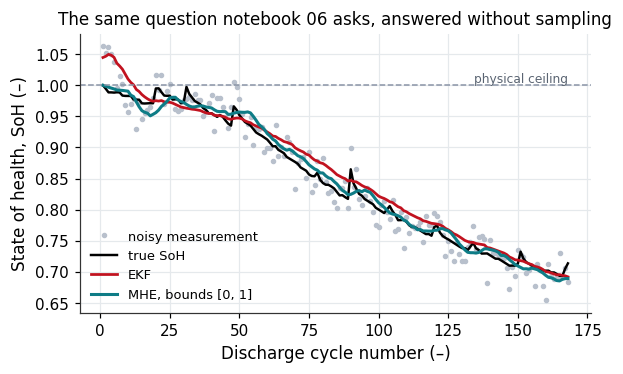

saved fig/f_otwin05_estimators.png


'fig/f_otwin05_estimators.png'

In [6]:
fig, ax = plt.subplots(figsize=(6.0, 3.3))
ax.plot(cyc, y[:, 0], "o", color="#B8C0CC", ms=2.6, label="noisy measurement")
ax.plot(cyc, soh, "-", color=OBS, lw=1.6, label="true SoH")
ax.plot(cyc, xe, "-", color=RED, lw=1.8, label="EKF")
ax.plot(cyc, xm, "-", color=TEAL, lw=2.0, label="MHE, bounds [0, 1]")
ax.axhline(1.0, color="#8A94A6", ls="--", lw=1.0)
ax.text(168, 1.005, "physical ceiling", fontsize=8, color="#5A6472", ha="right")
ax.set_xlabel("Discharge cycle number (–)"); ax.set_ylabel("State of health, SoH (–)")
ax.set_title("The same question notebook 06 asks, answered without sampling", fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc="lower left"); despine(ax)
save(fig, "f_otwin05_estimators")

## 3 · An observer that will not invent energy

A Kalman update is a least-squares step. Nothing in it knows about your energy function, so on
a passive system it will happily push the state to a point of *higher* stored energy than
physics allows. `EnergyConsistentObserver` rejects the part of a correction that would do that.

The fade model has no energy function, so this is shown on the flywheel from notebook 01, where
`H` is real. The tachometer is given a sustained false reading of +150 rad/s for eighty seconds,
and both filters are tuned to trust it.

*Look at:* over the excursion the EKF chases the lie (error 4.2 rad/s); the observer rejects
what the ports cannot explain (1.0 rad/s), **2.4× closer** to the truth. And one honest line:
on this problem neither filter raises `H` over a step, because the flywheel's own run-down
between samples is larger than any correction — the constraint shows in the state error, not
in the energy audit.

In [7]:
I_fw, C1, C2 = 1200.0, 0.020, 2.0e-6
fly = PortHamiltonianSystem(
    H=lambda x: x[0]**2/(2*I_fw), grad_H=lambda x: np.array([x[0]/I_fw]),
    J=lambda x: np.zeros((1, 1)),
    R=lambda x: np.array([[C1 + C2*(abs(x[0])/I_fw)**2]]),
    g=lambda x: np.array([[1.0]]), n_states=1, n_inputs=1)

class Flywheel:
    n_states, n_inputs = 1, 0
    def rhs(self, x, u, t):     return (fly.J(x) - fly.R(x)) @ fly.grad_H(x)
    def observe(self, x, u, t): return np.array([x[0]/I_fw])          # a tachometer, rad/s

tf = np.linspace(0, 3600, 361)
truth = integrate_phs(fly, np.array([I_fw*700.0]), tf, np.zeros((len(tf), 1)))["x"][:, 0]
rng2 = np.random.default_rng(3)
yw = (truth/I_fw + rng2.normal(0, 8.0, len(tf))).reshape(-1, 1)       # noisy speed, rad/s
yw[40:48, 0] += 150.0                                                 # a sustained spurious reading

Qw, Rw, Pw = np.array([[1e2]]), np.array([[16.0]]), np.array([[1e6]])
ekf_w = ExtendedKalmanFilter(Flywheel(), Qw, Rw, Pw, x0=np.array([I_fw*700.0])).filter(yw, None, tf)
eco_w = EnergyConsistentObserver(Flywheel(), Qw, Rw, Pw, x0=np.array([I_fw*700.0]),
                                 energy=lambda x: fly.energy(x)).filter(yw, None, tf)

H_ekf = np.array([fly.energy(np.array([v])) for v in ekf_w.x[:, 0]])
H_eco = np.array([fly.energy(np.array([v])) for v in eco_w.x[:, 0]])
w_err = lambda X: float(np.sqrt(((X - truth)**2).mean())/I_fw)
exc = slice(40, 60)
print("ports are closed, so stored energy must never increase over a step.")
print("EKF                      : %d steps raise H | speed RMSE %.3f rad/s | over the excursion %.3f"
      % ((np.diff(H_ekf) > 0).sum(), w_err(ekf_w.x[:, 0]),
         float(np.sqrt(((ekf_w.x[exc, 0]-truth[exc])**2).mean())/I_fw)))
print("EnergyConsistentObserver : %d steps raise H | speed RMSE %.3f rad/s | over the excursion %.3f"
      % ((np.diff(H_eco) > 0).sum(), w_err(eco_w.x[:, 0]),
         float(np.sqrt(((eco_w.x[exc, 0]-truth[exc])**2).mean())/I_fw)))
print()


ports are closed, so stored energy must never increase over a step.
EKF                      : 0 steps raise H | speed RMSE 1.787 rad/s | over the excursion 4.173
EnergyConsistentObserver : 0 steps raise H | speed RMSE 0.732 rad/s | over the excursion 1.008



## 4 · Change one thing

- **Trust the sensor less.** Raise `Rm` from `4e-4` to `4e-3` in section 2. The EKF's excursion
  shrinks — and so does its ability to follow the real fade. The MHE keeps both.
- **Move the bound.** Set `bounds=[(0.0, 0.95)]`. The estimator now enforces something false;
  watch the error grow. A constraint is information only when it is true.
- **A longer lie.** In section 3 make the excursion `yw[40:80]`. The observer holds; the EKF drifts
  further.

In [8]:
# Try it: the same fault, an EKF that trusts the sensor ten times less.
ekf_c = ExtendedKalmanFilter(mdl, Q, np.array([[4e-3]]), P0, x0=np.array([1.0])).filter(y, us, ts)
print("EKF, R x10 : max state %.4f | steps > 1.0 %d | RMSE %.4f"
      % (ekf_c.x[:, 0].max(), (ekf_c.x[:, 0] > 1.0).sum(), np.sqrt(((ekf_c.x[:, 0]-soh)**2).mean())))
print("MHE bounded: max state %.4f | steps > 1.0 %d | RMSE %.4f" % (xm.max(), (xm > 1.0).sum(), np.sqrt(((xm-soh)**2).mean())))


EKF, R x10 : max state 1.0241 | steps > 1.0 11 | RMSE 0.0277
MHE bounded: max state 1.0000 | steps > 1.0 0 | RMSE 0.0120


## What you learned

- Resampled data is partly invented; `coverage` tells you how much. Report it.
- A model for otwin is two methods: `rhs` and `observe`.
- An unconstrained filter returns impossible states and is *less* accurate for it. Bounds are data.
- An observer that knows `H` rejects corrections that would create energy.

**Next:** [notebook 06](otwin_06_the_twin_that_says_no.ipynb) — recording what a twin can answer,
and refusing the rest.

---
*For CI, not for you.*

In [9]:
# Headline numbers for this notebook are structural, not reproductions.
REFERENCE = [
    ("EKF states above the physical ceiling", int((xe > 1.0).sum()),        12,     0),
    ("MHE states above the physical ceiling", int((xm > 1.0).sum()),        0,      0),
    ("MHE RMSE better than EKF",              bool(np.sqrt(((xm-soh)**2).mean()) <
                                                   np.sqrt(((xe-soh)**2).mean())), True, 0),
    ("signal coverage below 1 after the hole", bool(coverage(v_u) < 0.9),   True, 0),
]
print(f"{'quantity':<52} {'this run':>14}  {'expected':>14}  {'match':>6}")
print("-"*94)
_bad = [n for n, got, ref, _ in REFERENCE if got != ref]
for name, got, ref, _ in REFERENCE:
    print(f"{name:<52} {str(got):>14}  {str(ref):>14}  {'yes' if got == ref else 'NO':>6}")
print()
print("all structural claims hold" if not _bad else f"FAILED: {_bad}")

quantity                                                   this run        expected   match
----------------------------------------------------------------------------------------------
EKF states above the physical ceiling                            12              12     yes
MHE states above the physical ceiling                             0               0     yes
MHE RMSE better than EKF                                       True            True     yes
signal coverage below 1 after the hole                         True            True     yes

all structural claims hold


In [10]:
# Regression test. Fails loudly if a headline number has drifted.
assert not _bad, f"headline numbers drifted from the original notebooks: {_bad}"
print("regression test passed")


regression test passed
